In [1]:


import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, random_split
import torchvision
import torchvision.transforms as T
import matplotlib.pyplot as plt
import numpy as np
from math import log

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


Using device: cuda


In [2]:
from torch.utils.data import Subset

transform = T.Compose([
T.Resize((128, 128)),
T.ToTensor(),
])


train_full = torchvision.datasets.CIFAR10(root="./data", train=True, download=True, transform=transform)
test_set = torchvision.datasets.CIFAR10(root="./data", train=False, download=True, transform=transform)


# Subset: ONLY FIRST 5,000 IMAGES
subset_size = 5000
train_subset = Subset(train_full, range(subset_size))


# Train/Val split
val_size = 500
train_size = subset_size - val_size
train_set, val_set = random_split(train_subset, [train_size, val_size])


batch_size = 16
train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_set, batch_size=batch_size, shuffle=False)
print(f"Train size: {train_size}, Val size: {val_size}")

Files already downloaded and verified
Files already downloaded and verified
Train size: 4500, Val size: 500


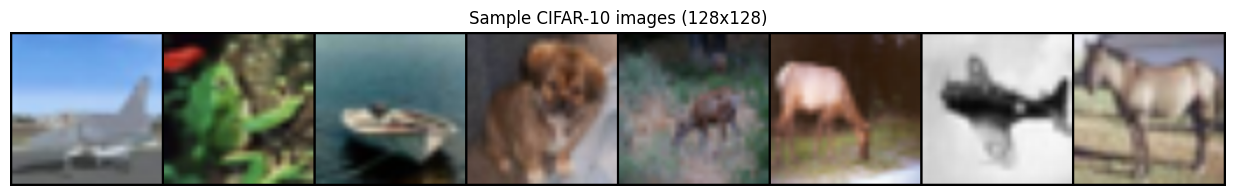

In [3]:


def show_batch_images(loader, n=8):
    x, y = next(iter(loader))
    x = x[:n]
    grid = torchvision.utils.make_grid(x, nrow=n, padding=2)
    plt.figure(figsize=(16,2))
    plt.imshow(np.transpose(grid.numpy(), (1,2,0)))
    plt.axis('off')
    plt.title("Sample CIFAR-10 images (128x128)")
    plt.show()

show_batch_images(train_loader, n=8)


In [4]:


class GaussianLikelihood(nn.Module):
    def __init__(self):
        super().__init__()

    def forward(self, x, mu, sigma):
        # x, mu, sigma same shape
        # Clip sigma to avoid numerical issues
        sigma = torch.clamp(sigma, min=1e-5)
        # log N(x | mu, sigma)
        log_prob = -0.5 * (((x - mu) / sigma) ** 2 + 2 * torch.log(sigma * (2 * np.pi) ** 0.5))
        return log_prob


In [5]:

class AnalysisTransform(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3,   128, kernel_size=5, stride=2, padding=2)  # H/2
        self.conv2 = nn.Conv2d(128, 128, kernel_size=5, stride=2, padding=2)  # H/4
        self.conv3 = nn.Conv2d(128, 192, kernel_size=5, stride=2, padding=2)  # H/8
        self.conv4 = nn.Conv2d(192, 192, kernel_size=3, stride=1, padding=1)  # same H/8

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = F.relu(self.conv2(x))
        x = F.relu(self.conv3(x))
        x = self.conv4(x)
        return x


In [6]:


class HyperAnalysis(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(192, 192, kernel_size=3, stride=1, padding=1)  # same
        self.conv2 = nn.Conv2d(192, 192, kernel_size=5, stride=2, padding=2)  # /2
        self.conv3 = nn.Conv2d(192, 128, kernel_size=5, stride=2, padding=2)  # /4

    def forward(self, y):
        z = F.relu(self.conv1(y))
        z = F.relu(self.conv2(z))
        z = self.conv3(z)
        return z


In [7]:


class HyperSynthesis(nn.Module):
    def __init__(self):
        super().__init__()
        self.tconv1 = nn.ConvTranspose2d(128, 192, kernel_size=5, stride=2, padding=2, output_padding=1)  # x2
        self.tconv2 = nn.ConvTranspose2d(192, 192, kernel_size=5, stride=2, padding=2, output_padding=1)  # x2
        self.conv_out = nn.Conv2d(192, 384, kernel_size=3, stride=1, padding=1)  # 2*192 (mu+sigma)

    def forward(self, z):
        z = F.relu(self.tconv1(z))
        z = F.relu(self.tconv2(z))
        z = self.conv_out(z)
        mu, sigma_param = torch.chunk(z, 2, dim=1)
        # Softplus to ensure sigma > 0
        sigma = F.softplus(sigma_param) + 1e-5
        return mu, sigma


In [8]:


class SynthesisTransform(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1  = nn.Conv2d(192, 192, kernel_size=3, stride=1, padding=1)
        self.tconv1 = nn.ConvTranspose2d(192, 192, kernel_size=5, stride=2, padding=2, output_padding=1)  # x2
        self.tconv2 = nn.ConvTranspose2d(192, 128, kernel_size=5, stride=2, padding=2, output_padding=1)  # x2
        self.tconv3 = nn.ConvTranspose2d(128,   3, kernel_size=5, stride=2, padding=2, output_padding=1)  # x2

    def forward(self, y):
        x = F.relu(self.conv1(y))
        x = F.relu(self.tconv1(x))
        x = F.relu(self.tconv2(x))
        x = torch.sigmoid(self.tconv3(x))  # output in [0,1]
        return x


In [9]:


class NeuralImageCodec(nn.Module):
    def __init__(self):
        super().__init__()
        self.g_a = AnalysisTransform()
        self.h_a = HyperAnalysis()
        self.h_s = HyperSynthesis()
        self.g_s = SynthesisTransform()
        self.gauss = GaussianLikelihood()

    def forward(self, x, training=True):
        # Encoder
        y = self.g_a(x)
        z = self.h_a(y)

        if training:
            # Add uniform noise to simulate quantization for backprop
            y_tilde = y + (torch.rand_like(y) - 0.5)
            z_tilde = z + (torch.rand_like(z) - 0.5)
        else:
            # Actual quantization at inference
            y_tilde = torch.round(y)
            z_tilde = torch.round(z)

        # Hyper-decoder predicts Gaussian params for y
        mu_y, sigma_y = self.h_s(z_tilde)

        # Decoder
        x_hat = self.g_s(y_tilde)

        return y_tilde, z_tilde, mu_y, sigma_y, x_hat


In [10]:
model = NeuralImageCodec().to(device)
print("Total parameters:", sum(p.numel() for p in model.parameters()) / 1e6, "M")


Total parameters: 7.312515 M


In [11]:


def bits_per_pixel(log_prob, num_pixels, batch_size):
    # log_prob: log p(...) for each latent element
    # Sum over all elements, convert from natural log to log2
    # bits = -log2 p = - log_e p / log_e 2
    log2 = log(2.0)
    total_log_prob = torch.sum(log_prob)
    bpp = - total_log_prob / (batch_size * num_pixels * log2)
    return bpp


In [12]:


def train_one_epoch(model, loader, optimizer, lambda_rd=0.01):
    model.train()
    total_loss = 0.0
    total_D = 0.0
    total_R = 0.0
    count = 0

    for x, _ in loader:
        x = x.to(device)
        B, C, H, W = x.shape
        num_pixels = H * W

        y_tilde, z_tilde, mu_y, sigma_y, x_hat = model(x, training=True)

        # Rate term for y (conditional Gaussian)
        log_p_y = model.gauss(y_tilde, mu_y, sigma_y)

        # For z, use a simple standard normal prior: N(0,1)
        # log N(z | 0,1) = -0.5 * (z^2 + log(2π))
        log_p_z = -0.5 * (z_tilde**2 + np.log(2 * np.pi))

        # Bits per pixel
        R_y = bits_per_pixel(log_p_y, num_pixels, B)
        R_z = bits_per_pixel(log_p_z, num_pixels, B)
        R = R_y + R_z

        # Distortion (L1)
        D = torch.mean(torch.abs(x - x_hat))

        loss = D + lambda_rd * R

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * B
        total_D += D.item() * B
        total_R += R.item() * B
        count += B

    return total_loss / count, total_D / count, total_R / count


@torch.no_grad()
def validate_one_epoch(model, loader, lambda_rd=0.01):
    model.eval()
    total_loss = 0.0
    total_D = 0.0
    total_R = 0.0
    count = 0

    for x, _ in loader:
        x = x.to(device)
        B, C, H, W = x.shape
        num_pixels = H * W

        y_tilde, z_tilde, mu_y, sigma_y, x_hat = model(x, training=False)
 # still use noise for validation estimate

        log_p_y = model.gauss(y_tilde, mu_y, sigma_y)
        log_p_z = -0.5 * (z_tilde**2 + np.log(2 * np.pi))

        R_y = bits_per_pixel(log_p_y, num_pixels, B)
        R_z = bits_per_pixel(log_p_z, num_pixels, B)
        R = R_y + R_z

        D = torch.mean(torch.abs(x - x_hat))

        loss = D + lambda_rd * R

        total_loss += loss.item() * B
        total_D += D.item() * B
        total_R += R.item() * B
        count += B

    return total_loss / count, total_D / count, total_R / count


In [13]:


num_epochs = 100          # you can increase to 50+ on GPU for good quality
lambda_rd = 0.01         # rate-distortion tradeoff
lr = 1e-4

optimizer = torch.optim.Adam(model.parameters(), lr=lr)

train_loss_hist = []
train_D_hist = []
train_R_hist = []

val_loss_hist = []
val_D_hist = []
val_R_hist = []

import random

def sample_new_subset(train_full, subset_size=5000, val_size=500):
    # randomly pick subset_size unique indices
    indices = random.sample(range(len(train_full)), subset_size)
    subset = Subset(train_full, indices)

    # split into train/val
    train_size = subset_size - val_size
    train_set, val_set = random_split(subset, [train_size, val_size])

    # dataloaders
    train_loader = DataLoader(train_set, batch_size=16, shuffle=True)
    val_loader = DataLoader(val_set, batch_size=16, shuffle=False)

    return train_loader, val_loader

for epoch in range(1, num_epochs + 1):
    print(f"\nEpoch {epoch}/{num_epochs}")

    train_loader, val_loader = sample_new_subset(train_full, subset_size=5000, val_size=500)

    train_loss, train_D, train_R = train_one_epoch(model, train_loader, optimizer)
    val_loss,   val_D,   val_R   = validate_one_epoch(model, val_loader)

    train_loss_hist.append(train_loss)
    train_D_hist.append(train_D)
    train_R_hist.append(train_R)

    val_loss_hist.append(val_loss)
    val_D_hist.append(val_D)
    val_R_hist.append(val_R)

    print(f"  Train - Loss: {train_loss:.4f}, D: {train_D:.4f}, R: {train_R:.4f}")
    print(f"  Val   - Loss: {val_loss:.4f}, D: {val_D:.4f}, R: {val_R:.4f}")



Epoch 1/100
  Train - Loss: 0.1209, D: 0.1057, R: 1.5149
  Val   - Loss: 0.1903, D: 0.1811, R: 0.9209

Epoch 2/100
  Train - Loss: 0.0638, D: 0.0505, R: 1.3333
  Val   - Loss: 0.1506, D: 0.1457, R: 0.4945

Epoch 3/100
  Train - Loss: 0.0514, D: 0.0386, R: 1.2742
  Val   - Loss: 0.1174, D: 0.1115, R: 0.5938

Epoch 4/100
  Train - Loss: 0.0463, D: 0.0337, R: 1.2655
  Val   - Loss: 0.0974, D: 0.0925, R: 0.4908

Epoch 5/100
  Train - Loss: 0.0418, D: 0.0292, R: 1.2638
  Val   - Loss: 0.0798, D: 0.0745, R: 0.5357

Epoch 6/100
  Train - Loss: 0.0369, D: 0.0242, R: 1.2690
  Val   - Loss: 0.0586, D: 0.0510, R: 0.7639

Epoch 7/100
  Train - Loss: 0.0346, D: 0.0219, R: 1.2647
  Val   - Loss: 0.0489, D: 0.0396, R: 0.9288

Epoch 8/100
  Train - Loss: 0.0333, D: 0.0207, R: 1.2637
  Val   - Loss: 0.0495, D: 0.0407, R: 0.8858

Epoch 9/100
  Train - Loss: 0.0320, D: 0.0194, R: 1.2623
  Val   - Loss: 0.0406, D: 0.0309, R: 0.9674

Epoch 10/100
  Train - Loss: 0.0312, D: 0.0186, R: 1.2579
  Val   - Loss

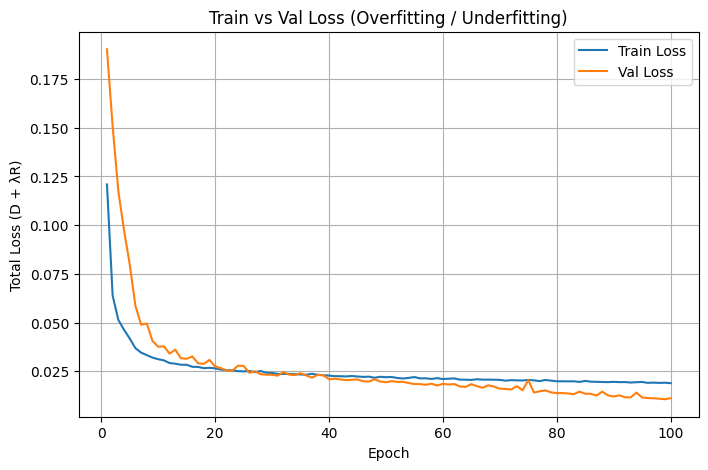

In [14]:


epochs = range(1, num_epochs + 1)

plt.figure(figsize=(8,5))
plt.plot(epochs, train_loss_hist, label="Train Loss")
plt.plot(epochs, val_loss_hist, label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Total Loss (D + λR)")
plt.title("Train vs Val Loss (Overfitting / Underfitting)")
plt.legend()
plt.grid(True)
plt.show()


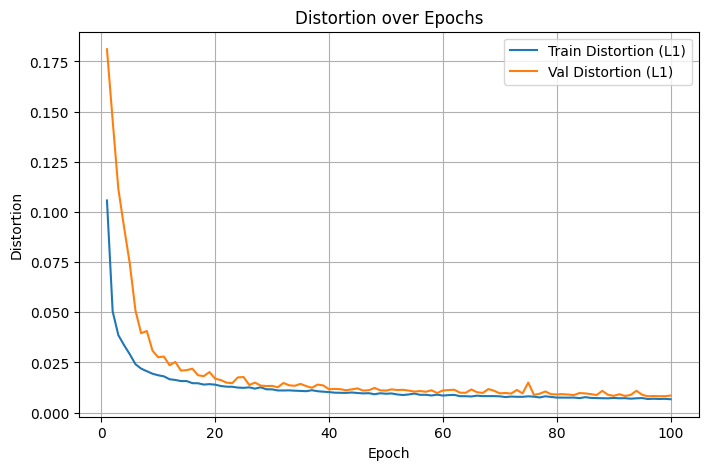

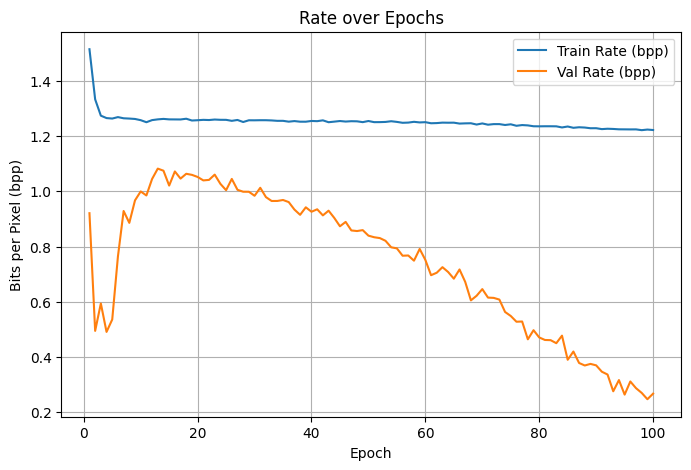

In [15]:


plt.figure(figsize=(8,5))
plt.plot(epochs, train_D_hist, label="Train Distortion (L1)")
plt.plot(epochs, val_D_hist,   label="Val Distortion (L1)")
plt.xlabel("Epoch")
plt.ylabel("Distortion")
plt.title("Distortion over Epochs")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8,5))
plt.plot(epochs, train_R_hist, label="Train Rate (bpp)")
plt.plot(epochs, val_R_hist,   label="Val Rate (bpp)")
plt.xlabel("Epoch")
plt.ylabel("Bits per Pixel (bpp)")
plt.title("Rate over Epochs")
plt.legend()
plt.grid(True)
plt.show()


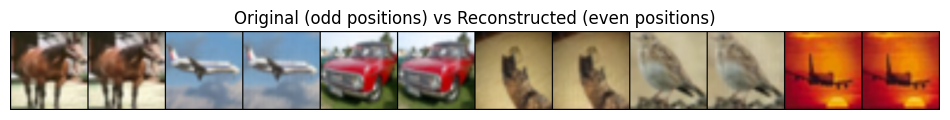

In [16]:


@torch.no_grad()
def show_reconstructions(model, loader, n=6):
    model.eval()
    x, _ = next(iter(loader))
    x = x.to(device)
    B = x.size(0)
    n = min(n, B)

    # Use true quantization at test-time
    y = model.g_a(x)
    z = model.h_a(y)
    y_tilde = torch.round(y)
    z_tilde = torch.round(z)
    mu_y, sigma_y = model.h_s(z_tilde)
    x_hat = model.g_s(y_tilde)

    x = x[:n].cpu()
    x_hat = x_hat[:n].cpu()

    # Make grid
    both = []
    for i in range(n):
        both.append(x[i])
        both.append(x_hat[i])
    grid = torchvision.utils.make_grid(both, nrow=2*n, padding=2)

    plt.figure(figsize=(2*n, 4))
    plt.imshow(np.transpose(grid.numpy(), (1,2,0)))
    plt.axis('off')
    plt.title("Original (odd positions) vs Reconstructed (even positions)")
    plt.show()

show_reconstructions(model, val_loader, n=6)


In [17]:
torch.save(model.state_dict(), "safety_backup.pth")


4K Image Loaded: 4738 x 3159


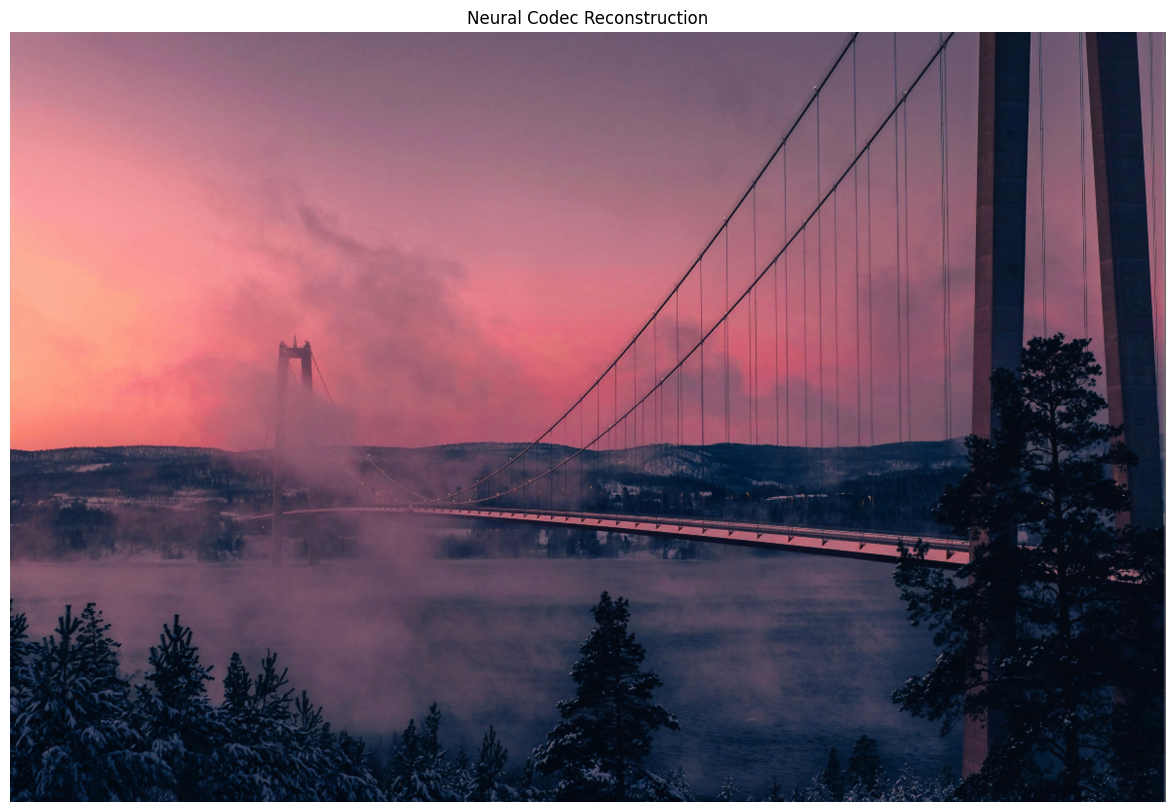


===== Neural Codec Estimate =====
Latent shape: (1, 192, 395, 593)
Total latent values: 44,973,120
Estimated Bits-per-pixel (naive latent storage): 24.0380 bpp

===== JPEG (quality 75) =====
JPEG size: 1142.21 KB
JPEG Bits-per-pixel: 0.6252 bpp


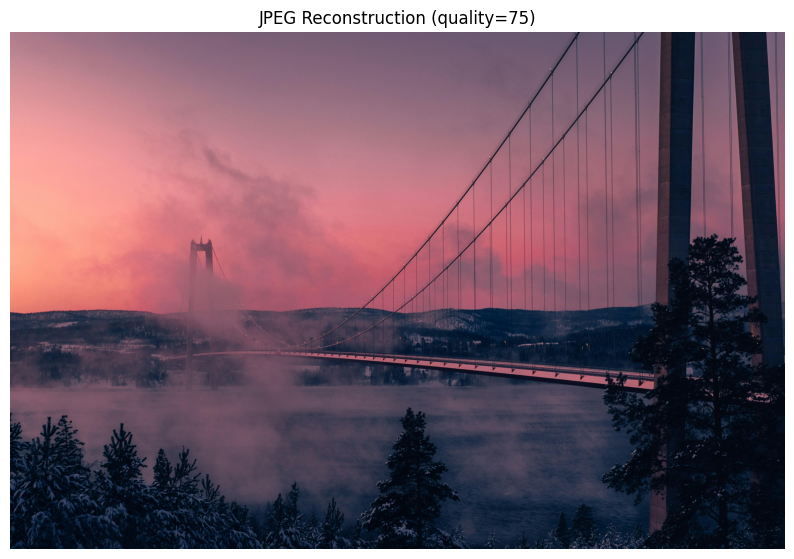

In [19]:


from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
import io
import math
import torchvision.transforms as T



img = Image.open(r'C:\Users\pragnay\OneDrive\Documents\ImageResizer\anders-jilden-AkUR27wtaxs-unsplash.jpg').convert("RGB")

W, H = img.size
print("4K Image Loaded:", W, "x", H)


to_tensor = T.ToTensor()
x_full = to_tensor(img).unsqueeze(0).to(device)   # (1,3,H,W)


with torch.no_grad():
    y = model.g_a(x_full)
    z = model.h_a(y)
    y_q = torch.round(y)
    z_q = torch.round(z)
    mu, sigma = model.h_s(z_q)
    x_hat = model.g_s(y_q)


x_np = x_full.squeeze(0).cpu().permute(1,2,0).numpy()
x_hat_np = x_hat.squeeze(0).cpu().permute(1,2,0).numpy()


plt.figure(figsize=(20,10))



plt.imshow(x_hat_np)
plt.title("Neural Codec Reconstruction")
plt.axis("off")

plt.show()





num_latent = y_q.numel()
bpp_latent = (num_latent * 8) / (H * W)

print(f"\n===== Neural Codec Estimate =====")
print(f"Latent shape: {tuple(y_q.shape)}")
print(f"Total latent values: {num_latent:,}")
print(f"Estimated Bits-per-pixel (naive latent storage): {bpp_latent:.4f} bpp")


# Compare with JPEG compression


# Save as JPEG in-memory
buf = io.BytesIO()
img.save(buf, format="JPEG", quality=75)  # quality = 75 (default JPEG)
jpeg_bytes = buf.getvalue()

jpeg_bpp = (len(jpeg_bytes) * 8) / (H * W)

print("\n===== JPEG (quality 75) =====")
print(f"JPEG size: {len(jpeg_bytes)/1024:.2f} KB")
print(f"JPEG Bits-per-pixel: {jpeg_bpp:.4f} bpp")

# Display JPEG reconstruction
jpeg_img = Image.open(io.BytesIO(jpeg_bytes))
jpeg_np = np.array(jpeg_img).astype(np.float32) / 255.0

plt.figure(figsize=(10,10))
plt.imshow(jpeg_np)
plt.title("JPEG Reconstruction (quality=75)")
plt.axis("off")
plt.show()
